# Typographic Attack Confusion Matrices — Per-Language

**Research question:** With *separate* per-language CLIP models (one per language,
each with its own image + text encoder), does a typographic attack written in language
X only fool the model trained on language X — or does it transfer to other models?

**Setup:**
- 4 independently-trained CLIP models: English, Chinese, Korean, Japanese
- 4 typographic attacks: target class name written in each language onto the image
- Dataset: STL-10 test set, 200 random images

**Outputs:**
1. 4×4 accuracy heatmap (rows = attack language, cols = model language)
2. 4×4 ASR heatmap (Attack Success Rate)
3. Per-model 10×10 confusion matrices under strongest attack

**Connection to prior work:** `updated_multilingual_consensus_colab.ipynb` showed that
a shared encoder causes all languages to collapse together under attack. This notebook
tests whether separate encoders provide language-specific isolation.

## 0. Install & imports

Run the install cell **before** any `import open_clip`. If you already imported
`open_clip` in this session, the second block purges the stale import.

In [1]:
import subprocess, sys

# Remove scikit-learn and scipy FIRST — if either is present, transformers'
# is_sklearn_available() returns True and auto-imports sklearn deep inside
# generation/candidate_generator.py, which pulls scipy._sparsetools (a native
# DLL blocked by Windows Application Control policy).
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "scikit-learn", "scipy"],
    capture_output=True,
)

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "open_clip_torch", "transformers", "datasets", "ftfy", "sentencepiece",
    "seaborn", "protobuf", "tiktoken",
])
print("packages installed into:", sys.executable)

packages installed into: D:\ian\2026summer\.venv\Scripts\python.exe


In [2]:
import importlib, sys, os, platform, random, json, time

import transformers  # must import BEFORE open_clip
print("transformers", transformers.__version__)

if "open_clip" in sys.modules:
    import open_clip.hf_model as _oc_hf
    if _oc_hf.transformers is None:
        print("Reloading open_clip (stale import without transformers)...")
        for name in list(sys.modules):
            if name == "open_clip" or name.startswith("open_clip."):
                del sys.modules[name]
        importlib.invalidate_caches()

import torch, torch.nn.functional as F
import numpy as np
import torchvision
import matplotlib.pyplot as plt
import seaborn as sns
# sklearn/scipy blocked by Windows Application Control — pure-numpy replacement below
import open_clip
from transformers import (
    AutoModel, AutoProcessor, AutoTokenizer, AutoImageProcessor,
    ChineseCLIPModel, ChineseCLIPProcessor, PreTrainedModel,
)
from PIL import Image, ImageDraw, ImageFont

# transformers 5.x (PR #42270) creates `all_tied_weights_keys` in post_init(),
# but the Japanese model's trust_remote_code CLYPModel never calls post_init(),
# so loading crashes with: 'CLYPModel' object has no attribute 'all_tied_weights_keys'.
# Provide a harmless class-level default so remote-code models fall back to it.
# (Weight-tying is a no-op for these inference-only feature extractors.)
if "all_tied_weights_keys" not in vars(PreTrainedModel):
    PreTrainedModel.all_tied_weights_keys = {}

import open_clip.hf_model as _oc_hf
assert _oc_hf.transformers is not None, "restart kernel and re-run from top"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
assert DEVICE == "cuda", "Enable a GPU runtime"
print("device:", torch.cuda.get_device_name(0))
torch.manual_seed(0); np.random.seed(0)

transformers 5.12.1


device: NVIDIA GeForce RTX 5070 Ti


## 1. Per-language model wrappers

Four independently-trained CLIP models, each with its own image + text encoder.
All wrappers expose the same two methods returning L2-normalized features, so
a plain dot product gives cosine similarity.

In [3]:
LANGS = ["en", "zh", "ko", "ja"]

CLASSES = {
    "en": ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"],
    "zh": ["飞机", "鸟", "汽车", "猫", "鹿", "狗", "马", "猴子", "船", "卡车"],
    "ko": ["비행기", "새", "자동차", "고양이", "사슴", "개", "말", "원숭이", "배", "트럭"],
    "ja": ["飛行機", "鳥", "車", "猫", "鹿", "犬", "馬", "猿", "船", "トラック"],
}
TMPL = {
    "en": "a photo of a {}.",
    "zh": "一张{}的照片。",
    "ko": "{}의 사진.",
    "ja": "{}の写真。",
}


def classify(model, imgs, words):
    """Zero-shot classify imgs against words. Returns array of predicted class indices."""
    imf = model.embed_images(imgs)
    tf  = model.embed_texts(words)
    return (imf @ tf.t()).argmax(-1).cpu().numpy()


def _clip_features(outputs):
    """Unwrap get_*_features output to a [N, D] tensor.

    transformers 5.x returns BaseModelOutputWithPooling from get_image_features /
    get_text_features. The projected CLIP embedding lives in .pooler_output
    (transformers overwrites that field with visual/text_projection output).

    IMPORTANT: do NOT read .pooler_output from vision_model/text_model directly —
    that gives unprojected 768-d features, not 512-d CLIP embeddings.
    """
    if torch.is_tensor(outputs):
        return outputs
    if getattr(outputs, "pooler_output", None) is not None:
        return outputs.pooler_output
    raise TypeError(
        f"Expected tensor or ModelOutput with pooler_output, got {type(outputs)}"
    )


class EnCLIP:
    lang = "en"
    def __init__(self):
        self.m, _, self.pp = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
        self.m = self.m.to(DEVICE).eval()
        self.tok = open_clip.get_tokenizer("ViT-B-32")

    @torch.no_grad()
    def embed_images(self, imgs):
        x = torch.stack([self.pp(im) for im in imgs]).to(DEVICE)
        return F.normalize(self.m.encode_image(x), dim=-1)

    @torch.no_grad()
    def embed_texts(self, words):
        t = self.tok([TMPL["en"].format(w) for w in words]).to(DEVICE)
        return F.normalize(self.m.encode_text(t), dim=-1)


class ZhCLIP:
    lang = "zh"
    def __init__(self):
        self.m = ChineseCLIPModel.from_pretrained("OFA-Sys/chinese-clip-vit-base-patch16").to(DEVICE).eval()
        self.p = ChineseCLIPProcessor.from_pretrained("OFA-Sys/chinese-clip-vit-base-patch16")

    @torch.no_grad()
    def embed_images(self, imgs):
        pv = self.p(images=imgs, return_tensors="pt").pixel_values.to(DEVICE)
        outputs = self.m.get_image_features(pixel_values=pv)
        return F.normalize(_clip_features(outputs), dim=-1)

    @torch.no_grad()
    def embed_texts(self, words):
        t = self.p(text=[TMPL["zh"].format(w) for w in words], padding=True, return_tensors="pt").to(DEVICE)
        outputs = self.m.get_text_features(
            input_ids=t["input_ids"],
            attention_mask=t["attention_mask"],
            token_type_ids=t.get("token_type_ids"),
        )
        return F.normalize(_clip_features(outputs), dim=-1)


class KoCLIP:
    lang = "ko"
    def __init__(self):
        self.m = AutoModel.from_pretrained("Bingsu/clip-vit-base-patch32-ko").to(DEVICE).eval()
        self.p = AutoProcessor.from_pretrained("Bingsu/clip-vit-base-patch32-ko")

    @torch.no_grad()
    def embed_images(self, imgs):
        pv = self.p(images=imgs, return_tensors="pt").pixel_values.to(DEVICE)
        outputs = self.m.get_image_features(pixel_values=pv)
        return F.normalize(_clip_features(outputs), dim=-1)

    @torch.no_grad()
    def embed_texts(self, words):
        t = self.p(text=[TMPL["ko"].format(w) for w in words], padding=True, return_tensors="pt").to(DEVICE)
        outputs = self.m.get_text_features(
            input_ids=t["input_ids"], attention_mask=t["attention_mask"]
        )
        return F.normalize(_clip_features(outputs), dim=-1)


class JaCLIP:
    lang = "ja"
    def __init__(self):
        # transformers 5.x reads self.all_tied_weights_keys during from_pretrained,
        # but CLYPModel (trust_remote_code) never calls post_init() to create it.
        # Class-level default makes the lookup fall back harmlessly. (Repeated here
        # so it applies even if the imports cell wasn't re-run in this kernel.)
        from transformers import PreTrainedModel as _PTM
        if "all_tied_weights_keys" not in vars(_PTM):
            _PTM.all_tied_weights_keys = {}
        self.m   = AutoModel.from_pretrained("line-corporation/clip-japanese-base", trust_remote_code=True).to(DEVICE).eval()
        self.tok = AutoTokenizer.from_pretrained("line-corporation/clip-japanese-base", trust_remote_code=True)
        self.ip  = AutoImageProcessor.from_pretrained("line-corporation/clip-japanese-base", trust_remote_code=True)

    @torch.no_grad()
    def embed_images(self, imgs):
        pv = self.ip(images=imgs, return_tensors="pt").to(DEVICE)
        outputs = self.m.get_image_features(**pv)
        return F.normalize(_clip_features(outputs), dim=-1)

    @torch.no_grad()
    def embed_texts(self, words):
        # NOTE: do NOT pass return_tensors="pt" — the custom CLYP tokenizer
        # tensorizes internally and double-conversion throws TypeError.
        t = self.tok([TMPL["ja"].format(w) for w in words], padding=True)
        t = {k: v.to(DEVICE) for k, v in t.items()}
        outputs = self.m.get_text_features(**t)
        return F.normalize(_clip_features(outputs), dim=-1)


MODEL_CLS = {"en": EnCLIP, "zh": ZhCLIP, "ko": KoCLIP, "ja": JaCLIP}
print("Model classes defined:", list(MODEL_CLS.keys()))

Model classes defined: ['en', 'zh', 'ko', 'ja']


## 2. Typographic attack — `draw_word` + font setup

Renders a word onto an image in a white box. Uses OS-aware font paths so the
same notebook runs on Colab/Linux and Windows without changes.

> **Font sanity check:** always eyeball the strip before trusting results.
> Invisible "tofu" boxes silently invalidate the experiment.

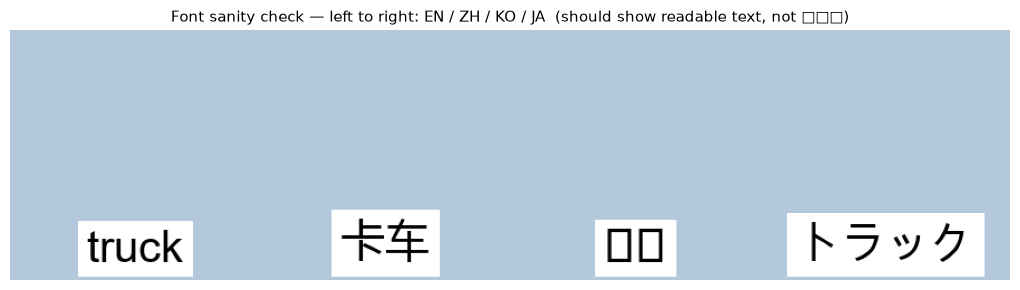

Fonts: C:\WINDOWS\Fonts\msyh.ttc | C:\WINDOWS\Fonts\arial.ttf


In [4]:
def _font_paths():
    """Return (cjk_font_path, latin_font_path) for the current OS."""
    if platform.system() == "Windows":
        winfonts = os.path.join(os.environ.get("WINDIR", "C:\\Windows"), "Fonts")
        cjk   = os.path.join(winfonts, "msyh.ttc")    # Microsoft YaHei (CJK + Latin)
        latin = os.path.join(winfonts, "arial.ttf")
        # Fall back to msyh for Latin too if arial is missing
        if not os.path.exists(latin):
            latin = cjk
    else:  # Linux / Colab
        cjk   = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
        latin = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
        if not os.path.exists(cjk):
            # Some Colab images put Noto here instead
            cjk = "/usr/share/fonts/opentype/noto/NotoSansCJKsc-Regular.otf"
    return cjk, latin

CJK_FONT, LATIN_FONT = _font_paths()

def _font_for(word):
    """Pick CJK font for CJK scripts, Latin font otherwise."""
    for ch in word:
        if ord(ch) > 0x2E7F:  # above basic Latin + common symbols → CJK/Hangul/etc.
            return CJK_FONT
    return LATIN_FONT


def draw_word(pil_img, word, font_path=None, size=40, where="bottom"):
    """Render `word` on `pil_img` in a white box. Returns a new PIL image."""
    if font_path is None:
        font_path = _font_for(word)
    img  = pil_img.convert("RGB").resize((224, 224), Image.BICUBIC)
    d    = ImageDraw.Draw(img)
    font = ImageFont.truetype(font_path, size)
    bb   = d.textbbox((0, 0), word, font=font)
    w, h = bb[2] - bb[0], bb[3] - bb[1]
    x    = (224 - w) // 2
    y    = (224 - h - 16) if where == "bottom" else (224 - h) // 2
    d.rectangle([x - 8, y - 8, x + w + 8, y + h + 12], fill=(255, 255, 255))
    d.text((x - bb[0], y - bb[1]), word, fill=(0, 0, 0), font=font)
    return img


# ── Font sanity-check: render one word per language and display ───────────────
os.makedirs("results", exist_ok=True)
base_img = Image.new("RGB", (224, 224), (180, 200, 220))  # plain blue-grey square

sample_words = {"en": "truck", "zh": "卡车", "ko": "트럭", "ja": "トラック"}
strip = Image.new("RGB", (224 * 4, 224), (200, 200, 200))
for i, lang in enumerate(LANGS):
    strip.paste(draw_word(base_img, sample_words[lang]), (i * 224, 0))
strip.save("results/font_check.png")

fig, ax = plt.subplots(figsize=(12, 3))
ax.imshow(strip); ax.axis("off")
ax.set_title('Font sanity check — left to right: EN / ZH / KO / JA  (should show readable text, not □□□)', fontsize=11)
plt.tight_layout(); plt.show()
print("Fonts:", CJK_FONT, "|", LATIN_FONT)

## 3. Load STL-10 + sample

200 random test images. `target[k]` is the adversarial target class for image k
(always different from `true[k]`).

In [5]:
from datasets import load_dataset

# Load ONLY the STL-10 test split from HuggingFace — a single ~100MB parquet file.
# torchvision.datasets.STL10 instead downloads a 2.6GB tarball that bundles 100k
# unlabeled images we never use; this avoids that entirely.
# Label order is the canonical STL-10 order, identical to CLASSES["en"]:
#   0 airplane, 1 bird, 2 car, 3 cat, 4 deer, 5 dog, 6 horse, 7 monkey, 8 ship, 9 truck
hf = load_dataset("tanganke/stl10", split="test")
label_key = "label" if "label" in hf.column_names else "labels"
image_key = "image" if "image" in hf.column_names else "img"

rng = random.Random(0)
idx    = rng.sample(range(len(hf)), 200)
rows   = hf.select(idx)  # one Arrow gather — fast random access
true   = np.array(rows[label_key])
target = np.array([rng.choice([c for c in range(10) if c != true[k]]) for k in range(len(idx))])
clean  = [im.convert("RGB") for im in rows[image_key]]

print(f"Loaded {len(clean)} images — class distribution:")
for c, name in enumerate(CLASSES["en"]):
    print(f"  {name:8s}: {(true == c).sum():3d}")

Loaded 200 images — class distribution:
  airplane:  18
  bird    :  17
  car     :  21
  cat     :  17
  deer    :  16
  dog     :  23
  horse   :  20
  monkey  :  15
  ship    :  29
  truck   :  24


## 4. Load all four models

Load once here before the attack loop — reloading per attack language would be
very slow. Expect ~1–2 min total on a T4.

In [6]:
models = {}
for lang, cls in MODEL_CLS.items():
    t0 = time.time()
    print(f"Loading {lang}...", end=" ", flush=True)
    models[lang] = cls()
    print(f"done ({time.time()-t0:.1f}s)")

print("\nAll models loaded.")

Loading en... 

D:\ian\2026summer\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


done (1.2s)
Loading zh... 

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

done (2.2s)
Loading ko... 

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

done (1.9s)
Loading ja... 

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

done (2.8s)

All models loaded.


## 5. Clean baseline accuracy

Accuracy on unattacked images for each model — the ceiling we are attacking from.

In [7]:
print("Clean baseline accuracy:")
clean_acc = {}
for lang in LANGS:
    preds_clean = classify(models[lang], clean, CLASSES[lang])
    clean_acc[lang] = (preds_clean == true).mean()
    print(f"  model_{lang}: {100*clean_acc[lang]:.1f}%")

Clean baseline accuracy:


  model_en: 98.5%


  model_zh: 97.0%


  model_ko: 98.5%


  model_ja: 14.0%


## 6. Cross-lingual attack loop

For every `attack_lang`: render the target class name written in `attack_lang` onto
each image. Then classify with every model. This produces a 4×4 grid of results.

> **Cropping guard:** we run the attack at `where="center"` as well as `"bottom"` to
> confirm results are not an artefact of model preprocessing cropping out bottom text.

In [8]:
# preds_attacked[attack_lang][model_lang] = np.array of shape (200,)
preds_attacked        = {}
preds_attacked_center = {}  # cropping sanity check

for attack_lang in LANGS:
    t0 = time.time()
    print(f"\nAttack language: {attack_lang}")

    attacked = [
        draw_word(clean[k], CLASSES[attack_lang][target[k]], where="bottom")
        for k in range(len(idx))
    ]
    attacked_center = [
        draw_word(clean[k], CLASSES[attack_lang][target[k]], where="center")
        for k in range(len(idx))
    ]

    preds_attacked[attack_lang]        = {}
    preds_attacked_center[attack_lang] = {}

    for model_lang in LANGS:
        p  = classify(models[model_lang], attacked,        CLASSES[model_lang])
        pc = classify(models[model_lang], attacked_center, CLASSES[model_lang])
        preds_attacked[attack_lang][model_lang]        = p
        preds_attacked_center[attack_lang][model_lang] = pc

        acc = (p  == true  ).mean()
        asr = (p  == target).mean()
        acc_c = (pc == true).mean()
        print(f"  model_{model_lang}: acc={100*acc:.1f}%  ASR={100*asr:.1f}%  "
              f"(center acc={100*acc_c:.1f}% — cropping check)")

    print(f"  [{time.time()-t0:.1f}s]")

print("\nAttack loop complete.")


Attack language: en


  model_en: acc=21.0%  ASR=79.0%  (center acc=14.0% — cropping check)


  model_zh: acc=59.5%  ASR=39.5%  (center acc=45.0% — cropping check)


  model_ko: acc=29.0%  ASR=70.5%  (center acc=20.0% — cropping check)


  model_ja: acc=16.5%  ASR=5.0%  (center acc=19.0% — cropping check)
  [2.9s]

Attack language: zh


...

  model_ja: acc=16.5%  ASR=5.0%  (center acc=18.0% — cropping check)
  [2.8s]

Attack language: ja


  model_en: acc=97.0%  ASR=0.5%  (center acc=91.5% — cropping check)


  model_zh: acc=89.5%  ASR=7.5%  (center acc=87.0% — cropping check)


  model_ko: acc=97.5%  ASR=0.5%  (center acc=95.5% — cropping check)


  model_ja: acc=17.0%  ASR=5.0%  (center acc=19.5% — cropping check)
  [2.8s]

Attack loop complete.


## 7. Compute 4×4 metric matrices

In [9]:
n = len(LANGS)
acc_matrix = np.zeros((n, n))
asr_matrix = np.zeros((n, n))

for i, attack_lang in enumerate(LANGS):
    for j, model_lang in enumerate(LANGS):
        p = preds_attacked[attack_lang][model_lang]
        acc_matrix[i, j] = (p == true  ).mean()
        asr_matrix[i, j] = (p == target).mean()

clean_acc_vec = np.array([clean_acc[l] for l in LANGS])

print("Accuracy matrix (rows=attack_lang, cols=model_lang):")
print(np.round(acc_matrix * 100, 1))
print("\nASR matrix:")
print(np.round(asr_matrix * 100, 1))
print("\nClean baseline:", np.round(clean_acc_vec * 100, 1))

Accuracy matrix (rows=attack_lang, cols=model_lang):
[[21.  59.5 29.  16.5]
 [97.5 84.  98.5 18.5]
 [96.5 97.5 97.5 16.5]
 [97.  89.5 97.5 17. ]]

ASR matrix:
[[79.  39.5 70.5  5. ]
 [ 0.  14.5  0.   4.5]
 [ 0.5  0.   0.   5. ]
 [ 0.5  7.5  0.5  5. ]]

Clean baseline: [98.5 97.  98.5 14. ]


## 8. 4×4 heatmaps

**Accuracy heatmap:** high values = model still mostly correct under attack (robust).  
**ASR heatmap:** high values = attack successfully redirected the model to the written class.

Look for diagonal structure: does a Chinese-script attack primarily hit the Chinese model?

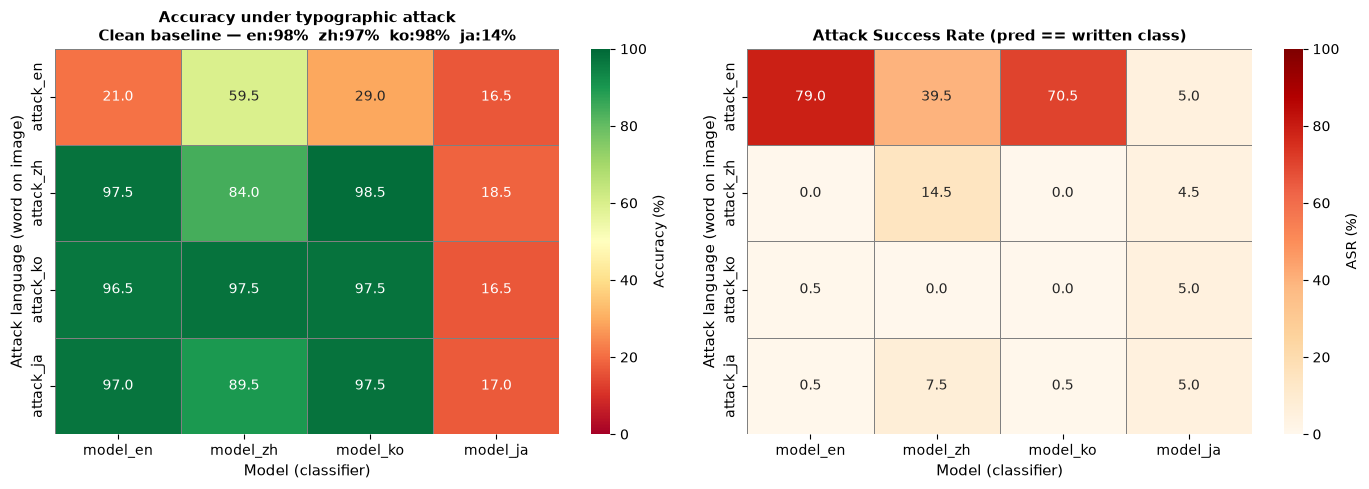

Saved → results/typographic_heatmaps.png


In [10]:
axis_labels = [f"model_{l}" for l in LANGS]
row_labels  = [f"attack_{l}" for l in LANGS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy heatmap ──────────────────────────────────────────────────────────
sns.heatmap(
    acc_matrix * 100,
    annot=True, fmt=".1f", cmap="RdYlGn",
    xticklabels=axis_labels, yticklabels=row_labels,
    vmin=0, vmax=100, linewidths=0.5, linecolor="grey",
    ax=axes[0], cbar_kws={"label": "Accuracy (%)"},
)
axes[0].set_title("Accuracy under typographic attack", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Model (classifier)", fontsize=11)
axes[0].set_ylabel("Attack language (word on image)", fontsize=11)

# Add clean baseline as a note above the first column header
clean_str = "  ".join([f"{l}:{100*clean_acc[l]:.0f}%" for l in LANGS])
axes[0].set_title(
    f"Accuracy under typographic attack\nClean baseline — {clean_str}",
    fontsize=11, fontweight="bold"
)

# ── ASR heatmap ───────────────────────────────────────────────────────────────
sns.heatmap(
    asr_matrix * 100,
    annot=True, fmt=".1f", cmap="OrRd",
    xticklabels=axis_labels, yticklabels=row_labels,
    vmin=0, vmax=100, linewidths=0.5, linecolor="grey",
    ax=axes[1], cbar_kws={"label": "ASR (%)"},
)
axes[1].set_title("Attack Success Rate (pred == written class)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Model (classifier)", fontsize=11)
axes[1].set_ylabel("Attack language (word on image)", fontsize=11)

plt.tight_layout()
plt.savefig("results/typographic_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/typographic_heatmaps.png")

## 9. Per-model 10×10 confusion matrices

For each model we pick the **attack language with the highest ASR** (the strongest
attack against that model) and show the resulting 10×10 class confusion matrix.
The diagonal shows correct predictions; off-diagonal mass shows where predictions
went — ideally, a typographic attack should push mass into the *written* class column.

D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 39134 (\N{CJK UNIFIED IDEOGRAPH-98DE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 40479 (\N{CJK UNIFIED IDEOGRAPH-9E1F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 27773 (\N{CJK UNIFIED IDEOGRAPH-6C7D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 36710 (\N{CJK UNIFIED IDEOGRAPH-8F66}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 29483 (\N{CJK UNIFIED IDEOGRAPH-732B}) miss

D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 39131 (\N{CJK UNIFIED IDEOGRAPH-98DB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 40165 (\N{CJK UNIFIED IDEOGRAPH-9CE5}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 36554 (\N{CJK UNIFIED IDEOGRAPH-8ECA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
D:\ian\2026summer\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 29356 (\N{CJK UNIFIED IDEOGRAPH-72AC}) miss

D:\ian\2026summer\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39134 (\N{CJK UNIFIED IDEOGRAPH-98DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ian\2026summer\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ian\2026summer\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 40479 (\N{CJK UNIFIED IDEOGRAPH-9E1F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ian\2026summer\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27773 (\N{CJK UNIFIED IDEOGRAPH-6C7D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\ian\2026summer\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36710 (\N{CJK UNIFIED IDEOGRAPH-8F66}) missing from font(s) DejaVu Sans.
  

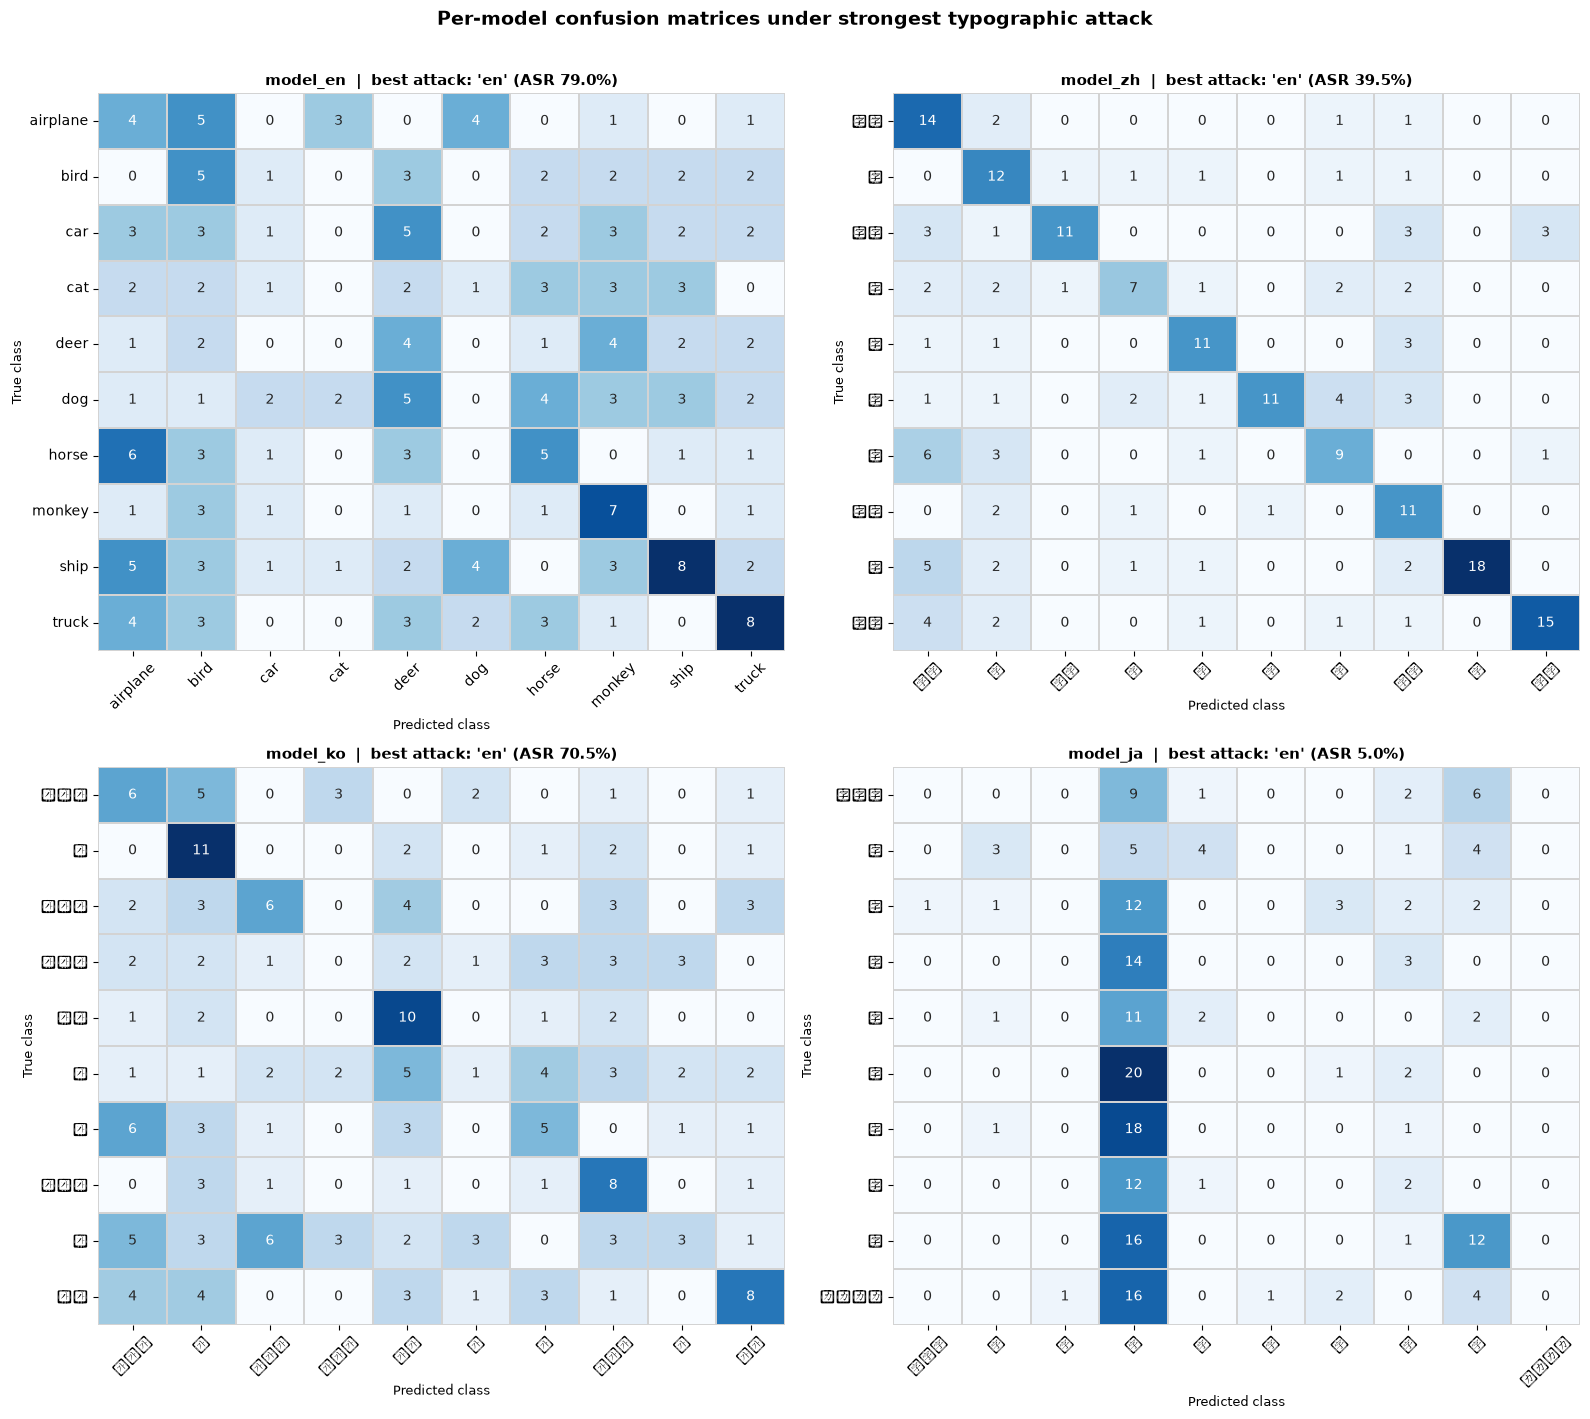

Saved → results/confusion_matrices.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for j, model_lang in enumerate(LANGS):
    # Find the attack language with highest ASR for this model
    col_asr   = asr_matrix[:, j]
    best_atk  = LANGS[col_asr.argmax()]
    best_asr  = col_asr.max()

    p  = preds_attacked[best_atk][model_lang]
    n_cls = 10
    cm = np.zeros((n_cls, n_cls), dtype=int)
    for t_i, p_i in zip(true, p):
        cm[t_i, p_i] += 1

    # Use this model's native class names on the axes
    cls_names = CLASSES[model_lang]

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=cls_names, yticklabels=cls_names,
        linewidths=0.3, linecolor="lightgrey",
        ax=axes[j], cbar=False,
    )
    axes[j].set_title(
        f"model_{model_lang}  |  best attack: '{best_atk}' (ASR {100*best_asr:.1f}%)",
        fontsize=11, fontweight="bold",
    )
    axes[j].set_xlabel("Predicted class", fontsize=9)
    axes[j].set_ylabel("True class", fontsize=9)
    axes[j].tick_params(axis="x", rotation=45)
    axes[j].tick_params(axis="y", rotation=0)

plt.suptitle(
    "Per-model confusion matrices under strongest typographic attack",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("results/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/confusion_matrices.png")

## 10. Save results

In [12]:
results = {
    "langs":      LANGS,
    "classes":    CLASSES,
    "n_images":   len(idx),
    "clean_acc":  {l: float(clean_acc[l]) for l in LANGS},
    "acc_matrix": acc_matrix.tolist(),   # [attack_lang][model_lang]
    "asr_matrix": asr_matrix.tolist(),
    "best_attack_per_model": {
        LANGS[j]: LANGS[int(asr_matrix[:, j].argmax())] for j in range(len(LANGS))
    },
}

out_path = "results/confusion_results.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"Saved → {out_path}")
print("\nSummary:")
for j, ml in enumerate(LANGS):
    best_atk = results["best_attack_per_model"][ml]
    print(f"  model_{ml}: clean {100*clean_acc[ml]:.1f}%  "
          f"| best attack='{best_atk}'  ASR={100*asr_matrix[LANGS.index(best_atk), j]:.1f}%")

Saved → results/confusion_results.json

Summary:
  model_en: clean 98.5%  | best attack='en'  ASR=79.0%
  model_zh: clean 97.0%  | best attack='en'  ASR=39.5%
  model_ko: clean 98.5%  | best attack='en'  ASR=70.5%
  model_ja: clean 14.0%  | best attack='en'  ASR=5.0%


## 11. How to read the results

### Diagonal vs. off-diagonal in the heatmaps

| Pattern | Interpretation |
|---|---|
| **Low accuracy / high ASR only on diagonal** | Attack is language-specific — Chinese text fools only the Chinese model. Separate encoders provide isolation. |
| **Low accuracy / high ASR across the whole row** | Attack transfers regardless of language — visual salience of the word overrides the language mismatch. |
| **Low accuracy / high ASR across the whole column** | That model is generally fragile to all written words, regardless of script. |
| **English row universally strongest** | English-script text is the most visually disruptive across all models, possibly because all models saw Latin-script pre-training data. |

### Confusion matrix columns

In a successful targeted typographic attack the predicted-class column corresponding
to the *written* class should light up (all rows push mass into one column).
Scattered predictions would indicate the attack degrades accuracy without successfully
redirecting to the intended class.

### Connection to the research arc

- `updated_multilingual_consensus_colab.ipynb`: shared encoder → languages always
  agree, even under attack → disagreement-based defence is impossible.
- **This notebook**: separate encoders → do languages disagree under attack?
  If diagonal structure exists, a cross-lingual ensemble *can* detect the attack
  (the attacked model disagrees with the others).